# 🎬 Netflix Titles - Complete Data Analysis

---
**Dataset:** `netflix_titles.csv`  
**Total Records:** 8,807 titles  
**Total Columns:** 12  

---

## 📦 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Chart style settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Netflix color palette
NETFLIX_RED  = '#E50914'
NETFLIX_DARK = '#141414'
PALETTE = [
    '#E50914', '#B20710', '#FF6B6B', '#FF8E53', '#FFC371',
    '#A8E063', '#56CCF2', '#2F80ED', '#9B51E0', '#F2994A',
    '#219653', '#EB5757', '#6FCF97', '#831010', '#F5F5F1'
]

print('Libraries imported successfully!')

Libraries imported successfully!


## 📂 2. Load the Dataset

In [2]:
df = pd.read_csv('netflix_titles.csv')

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 8,807 rows x 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 🔍 3. Exploratory Data Analysis (EDA)

In [3]:
# Column names, data types, and non-null counts
print('=' * 60)
print('Column Info & Data Types:')
print('=' * 60)
df.info()

Column Info & Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
# Descriptive statistics for all columns
print('=' * 60)
print('Descriptive Statistics:')
print('=' * 60)
df.describe(include='all').T

Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8804,15-Aug,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,1-Jan-20,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Check for missing values in each column
print('=' * 60)
print('Missing Values per Column:')
print('=' * 60)
missing       = df.isnull().sum()
missing_pct   = (missing / len(df) * 100).round(2)
missing_df    = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df    = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
print(missing_df)

Missing Values per Column:
            Count  Percentage (%)
director     2634           29.91
country       831            9.44
cast          825            9.37
date_added     10            0.11
rating          4            0.05
duration        3            0.03


## 🧹 4. Data Cleaning & Feature Engineering

In [6]:
df_clean = df.copy()

# Convert 'date_added' to datetime and extract date parts
df_clean['date_added']  = pd.to_datetime(df_clean['date_added'], dayfirst=True, errors='coerce')
df_clean['year_added']  = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean['month_name']  = df_clean['date_added'].dt.strftime('%b')

# Extract movie duration in minutes
movies_mask = df_clean['type'] == 'Movie'
df_clean.loc[movies_mask, 'duration_min'] = (
    df_clean.loc[movies_mask, 'duration']
    .str.extract(r'(\d+)')[0].astype(float)
)

# Extract number of seasons for TV Shows
shows_mask = df_clean['type'] == 'TV Show'
df_clean.loc[shows_mask, 'seasons'] = (
    df_clean.loc[shows_mask, 'duration']
    .str.extract(r'(\d+)')[0].astype(float)
)

# Fix misclassified ratings (some rows have duration in rating field)
invalid_ratings = ['74 min', '84 min', '66 min']
df_clean['rating'] = df_clean['rating'].replace({r: None for r in invalid_ratings})

print('Data cleaning complete! New columns added:')
print('  -> year_added, month_added, month_name')
print('  -> duration_min  (movies only, in minutes)')
print('  -> seasons       (TV shows only)')
df_clean[['title', 'type', 'date_added', 'year_added', 'duration_min', 'seasons']].head()

Data cleaning complete! New columns added:
  -> year_added, month_added, month_name
  -> duration_min  (movies only, in minutes)
  -> seasons       (TV shows only)


,title,type,date_added,year_added,duration_min,seasons
0,Dick Johnson Is Dead,Movie,2021-09-25,2021.0,90.0,NaN
1,Blood & Water,TV Show,2021-09-24,2021.0,NaN,2.0
2,Ganglands,TV Show,2021-09-24,2021.0,NaN,1.0
3,Jailbirds New Orleans,TV Show,2021-09-24,2021.0,NaN,1.0
4,Kota Factory,TV Show,2021-09-24,2021.0,NaN,2.0


## 📊 5. Visualizations

### 5.1 🍕 Content Type Distribution: Movies vs TV Shows

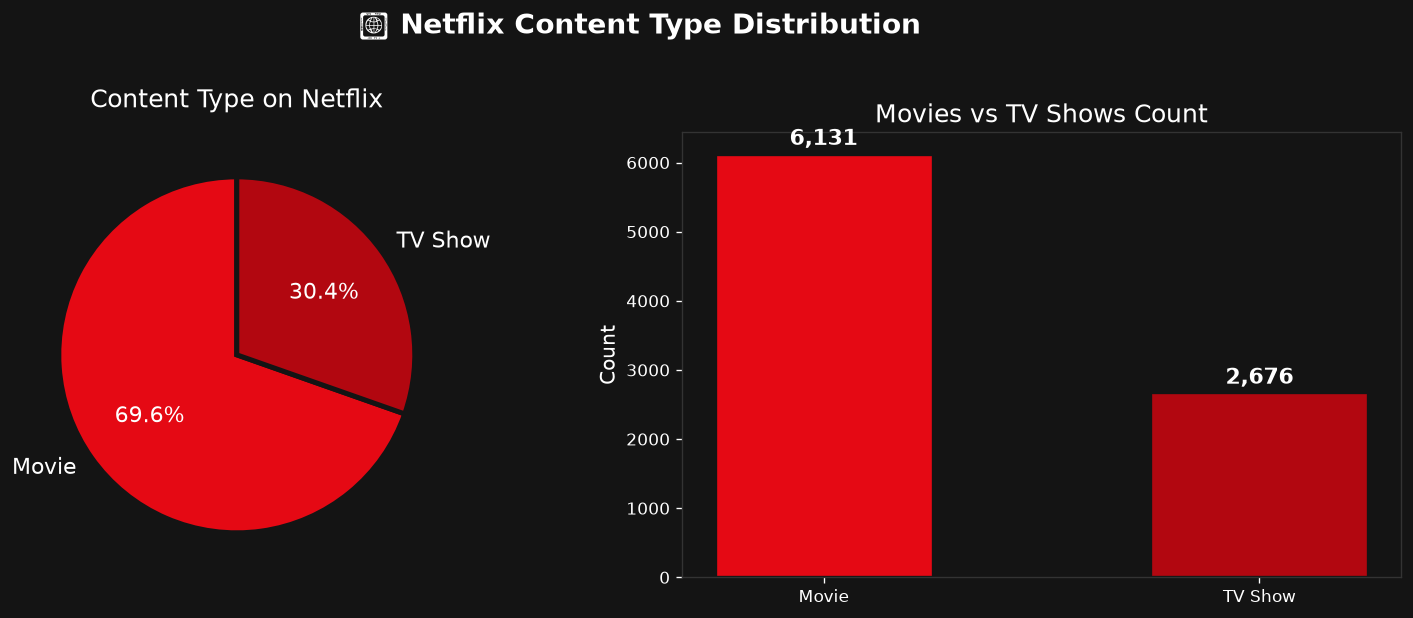

In [7]:
type_counts = df_clean['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(NETFLIX_DARK)

# --- Pie chart ---
ax1 = axes[0]
ax1.set_facecolor(NETFLIX_DARK)
wedges, texts, autotexts = ax1.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_RED, '#B20710'],
    startangle=90,
    wedgeprops={'edgecolor': NETFLIX_DARK, 'linewidth': 3}
)
for t in texts + autotexts:
    t.set_color('white')
    t.set_fontsize(13)
ax1.set_title('Content Type on Netflix', color='white', fontsize=15, pad=15)

# --- Bar chart ---
ax2 = axes[1]
ax2.set_facecolor(NETFLIX_DARK)
bars = ax2.bar(
    type_counts.index, type_counts.values,
    color=[NETFLIX_RED, '#B20710'], edgecolor=NETFLIX_DARK, linewidth=2, width=0.5
)
for bar, val in zip(bars, type_counts.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
        f'{val:,}', ha='center', va='bottom', color='white', fontsize=13, fontweight='bold'
    )
ax2.tick_params(colors='white')
ax2.set_ylabel('Count', color='white', fontsize=12)
ax2.set_title('Movies vs TV Shows Count', color='white', fontsize=15)
ax2.spines[:].set_color('#333')

plt.suptitle('🎬 Netflix Content Type Distribution', color='white', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 📅 Content Added to Netflix per Year

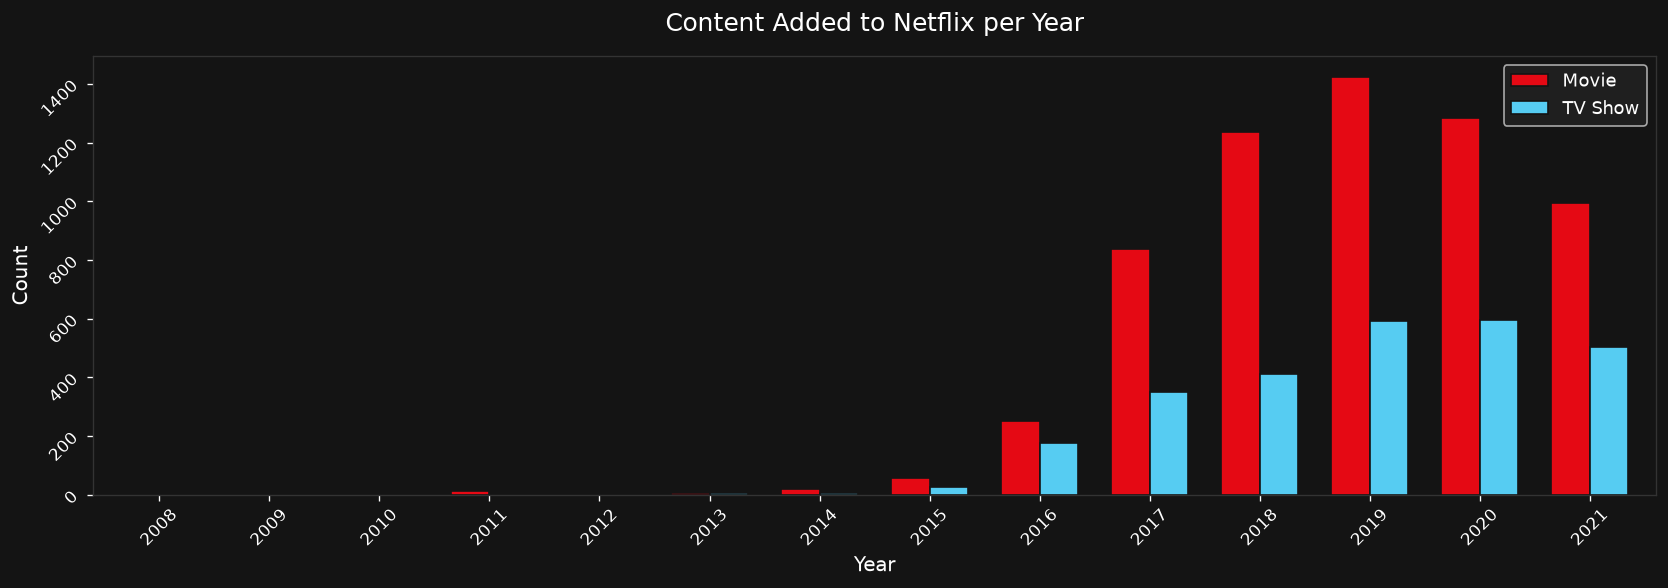

In [8]:
# Group by year and content type
yearly = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index.notna()]
yearly.index = yearly.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

yearly.plot(kind='bar', ax=ax, color=[NETFLIX_RED, '#56CCF2'], width=0.7, edgecolor=NETFLIX_DARK)

ax.set_title('Content Added to Netflix per Year', color='white', fontsize=15, pad=15)
ax.set_xlabel('Year', color='white', fontsize=12)
ax.set_ylabel('Count', color='white', fontsize=12)
ax.tick_params(colors='white', rotation=45)
ax.legend(facecolor='#222', labelcolor='white', fontsize=11)
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

### 5.3 🌍 Top 15 Production Countries

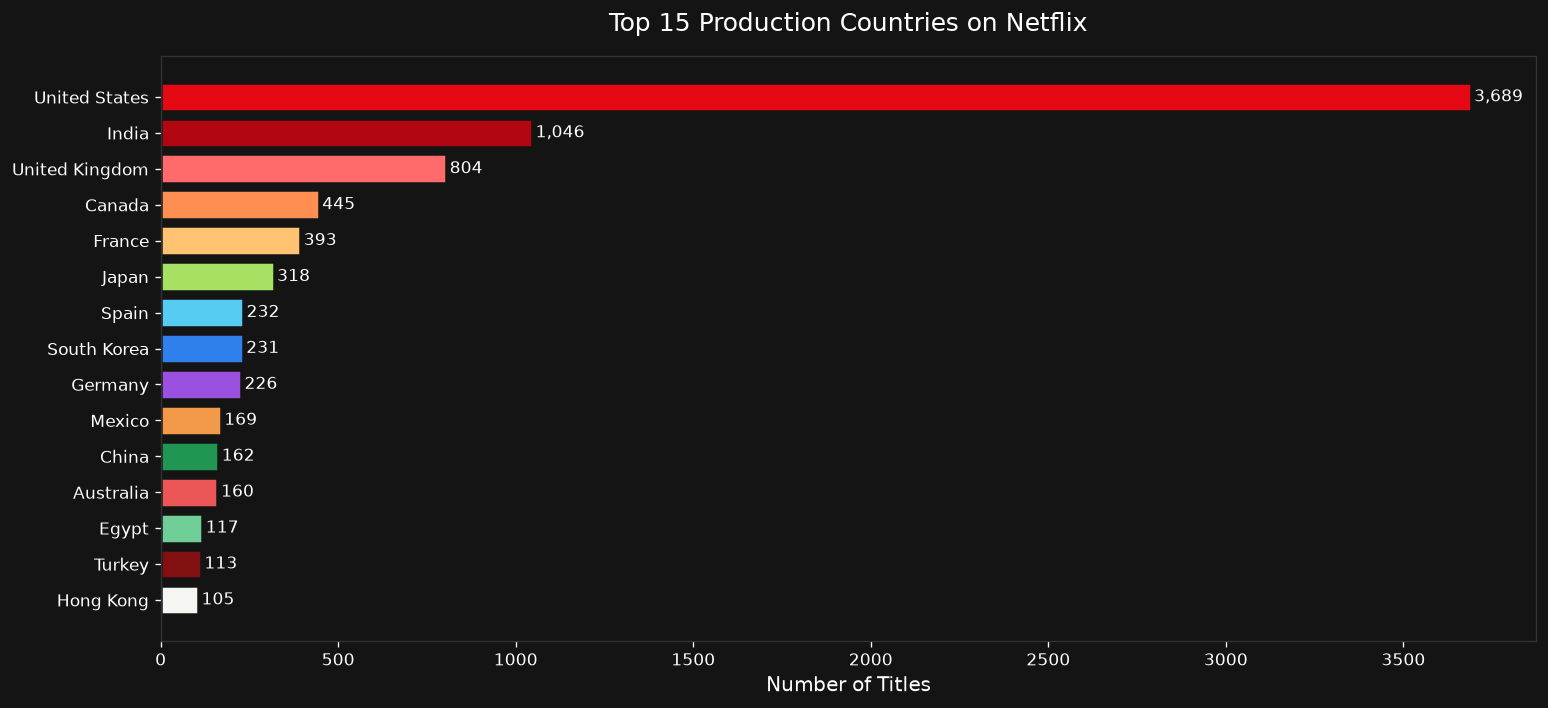

In [9]:
# Split multi-country entries and explode into individual rows
countries     = df_clean['country'].dropna().str.split(', ').explode()
top_countries = countries.value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

bars = ax.barh(
    top_countries.index[::-1], top_countries.values[::-1],
    color=PALETTE[:15][::-1], edgecolor=NETFLIX_DARK, linewidth=1.5
)
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(
        bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', color='white', fontsize=10
    )

ax.set_title('Top 15 Production Countries on Netflix', color='white', fontsize=15, pad=15)
ax.set_xlabel('Number of Titles', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

### 5.4 🎭 Top 15 Genres (Listed In)

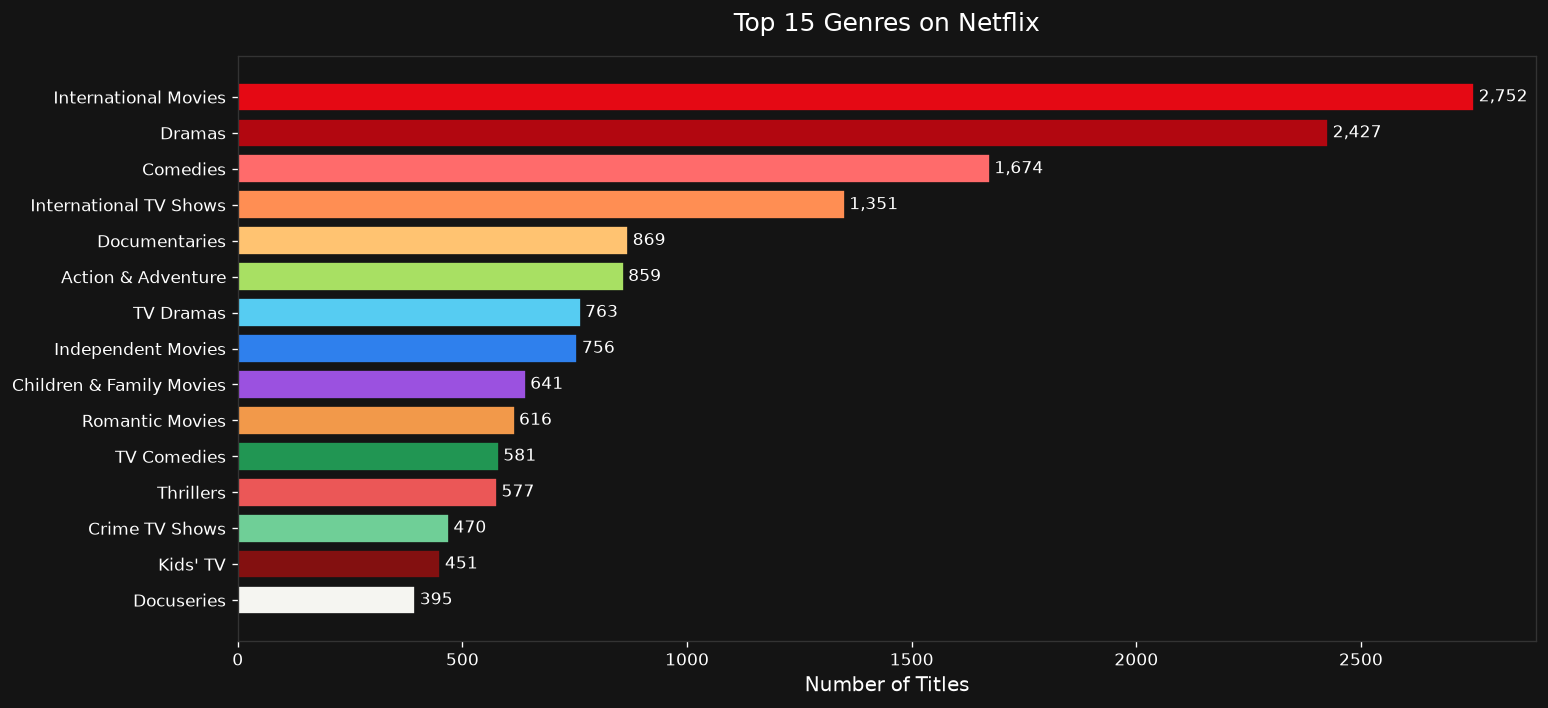

In [10]:
# Split multi-genre entries and explode
genres     = df_clean['listed_in'].dropna().str.split(', ').explode()
top_genres = genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

bars = ax.barh(
    top_genres.index[::-1], top_genres.values[::-1],
    color=PALETTE[:15][::-1], edgecolor=NETFLIX_DARK
)
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(
        bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', color='white', fontsize=10
    )

ax.set_title('Top 15 Genres on Netflix', color='white', fontsize=15, pad=15)
ax.set_xlabel('Number of Titles', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

### 5.5 🔞 Content Rating Distribution

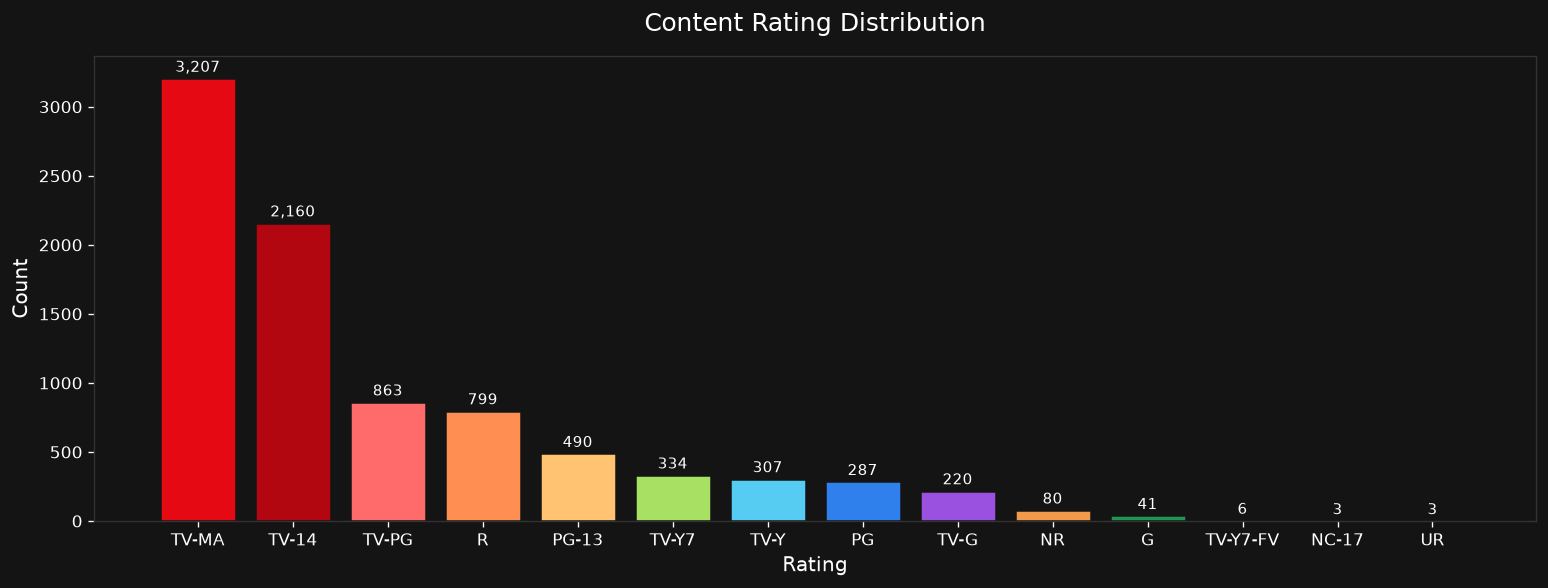

In [11]:
# Exclude any rows where rating accidentally contains duration values
rating_counts = df_clean['rating'].dropna().value_counts()
rating_counts = rating_counts[~rating_counts.index.str.contains('min', na=False)]

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

bars = ax.bar(
    rating_counts.index, rating_counts.values,
    color=PALETTE[:len(rating_counts)], edgecolor=NETFLIX_DARK, linewidth=1.5
)
for bar, val in zip(bars, rating_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
        f'{val:,}', ha='center', va='bottom', color='white', fontsize=9
    )

ax.set_title('Content Rating Distribution', color='white', fontsize=15, pad=15)
ax.set_xlabel('Rating', color='white', fontsize=12)
ax.set_ylabel('Count', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

### 5.6 ⏱️ Movie Duration Distribution (in Minutes)

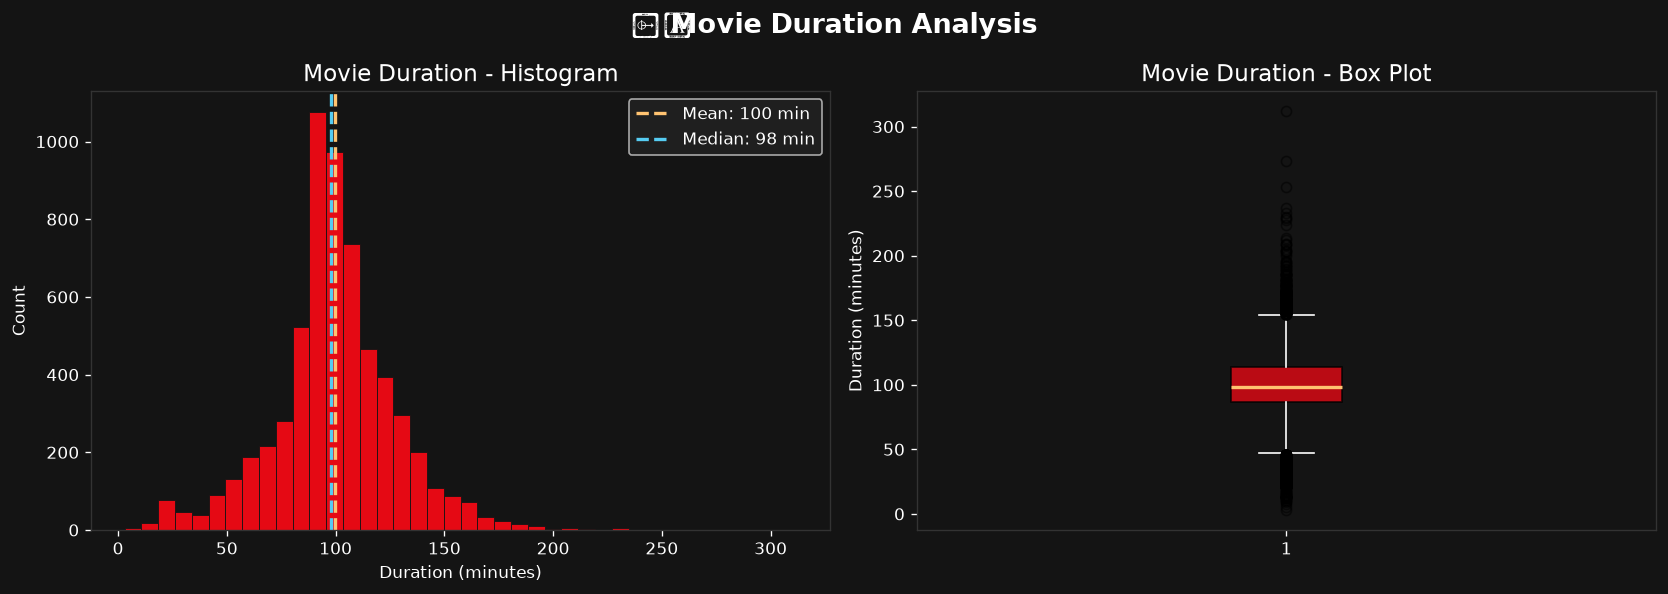

Movie Duration Statistics:
  Mean:    99.6 minutes
  Median:  98 minutes
  Min:     3 minutes
  Max:     312 minutes
  Std Dev: 28.3 minutes


In [12]:
movie_dur = df_clean[df_clean['type'] == 'Movie']['duration_min'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(NETFLIX_DARK)

# --- Histogram ---
ax1 = axes[0]
ax1.set_facecolor(NETFLIX_DARK)
ax1.hist(movie_dur, bins=40, color=NETFLIX_RED, edgecolor=NETFLIX_DARK, linewidth=0.5)
ax1.axvline(
    movie_dur.mean(), color='#FFC371', linewidth=2, linestyle='--',
    label=f'Mean: {movie_dur.mean():.0f} min'
)
ax1.axvline(
    movie_dur.median(), color='#56CCF2', linewidth=2, linestyle='--',
    label=f'Median: {movie_dur.median():.0f} min'
)
ax1.set_title('Movie Duration - Histogram', color='white', fontsize=14)
ax1.set_xlabel('Duration (minutes)', color='white')
ax1.set_ylabel('Count', color='white')
ax1.tick_params(colors='white')
ax1.legend(facecolor='#222', labelcolor='white')
ax1.spines[:].set_color('#333')

# --- Box plot ---
ax2 = axes[1]
ax2.set_facecolor(NETFLIX_DARK)
bp = ax2.boxplot(
    movie_dur, patch_artist=True, vert=True,
    medianprops={'color': '#FFC371', 'linewidth': 2}
)
bp['boxes'][0].set_facecolor(NETFLIX_RED)
bp['boxes'][0].set_alpha(0.8)
for w in bp['whiskers'] + bp['caps']:
    w.set_color('white')
for flier in bp['fliers']:
    flier.set(marker='o', color='#FF6B6B', alpha=0.5)
ax2.set_title('Movie Duration - Box Plot', color='white', fontsize=14)
ax2.set_ylabel('Duration (minutes)', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#333')

plt.suptitle('⏱️ Movie Duration Analysis', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Movie Duration Statistics:')
print(f'  Mean:    {movie_dur.mean():.1f} minutes')
print(f'  Median:  {movie_dur.median():.0f} minutes')
print(f'  Min:     {movie_dur.min():.0f} minutes')
print(f'  Max:     {movie_dur.max():.0f} minutes')
print(f'  Std Dev: {movie_dur.std():.1f} minutes')

### 5.7 📺 Number of Seasons per TV Show

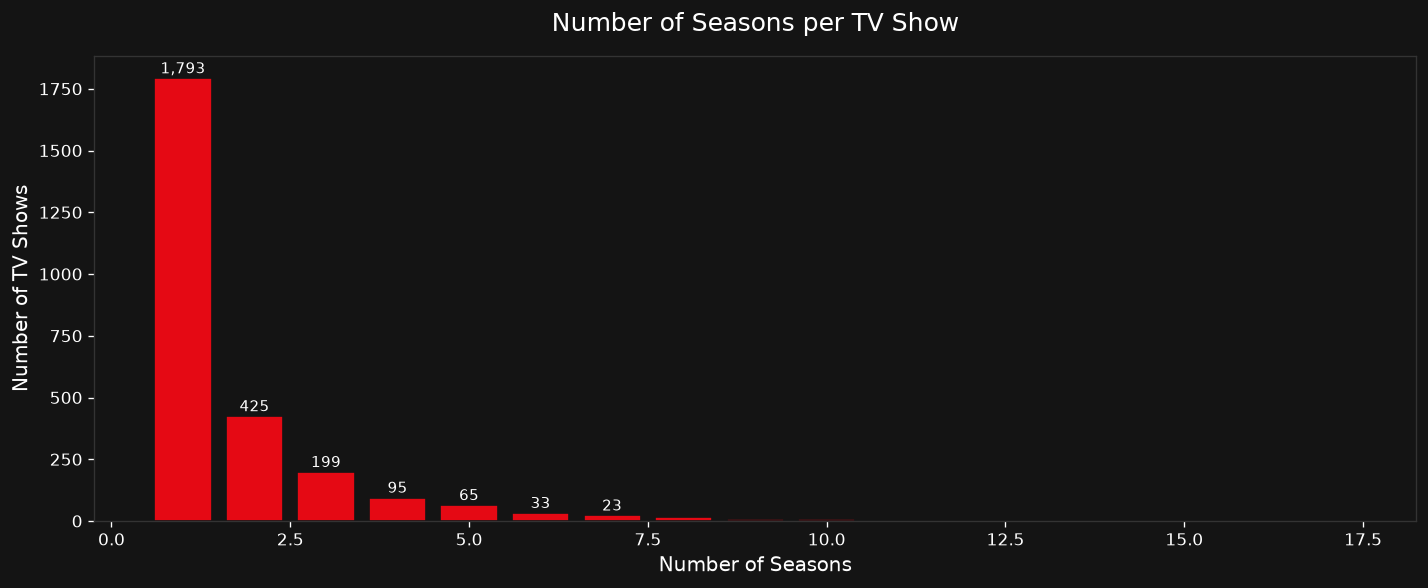

In [13]:
seasons_data  = df_clean[df_clean['type'] == 'TV Show']['seasons'].dropna()
season_counts = seasons_data.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

bars = ax.bar(
    season_counts.index.astype(int), season_counts.values,
    color=NETFLIX_RED, edgecolor=NETFLIX_DARK, linewidth=1
)
# Label bars with significant counts
for bar, val in zip(bars, season_counts.values):
    if val > 20:
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val:,}', ha='center', va='bottom', color='white', fontsize=9
        )

ax.set_title('Number of Seasons per TV Show', color='white', fontsize=15, pad=15)
ax.set_xlabel('Number of Seasons', color='white', fontsize=12)
ax.set_ylabel('Number of TV Shows', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

### 5.8 📆 Release Year Distribution

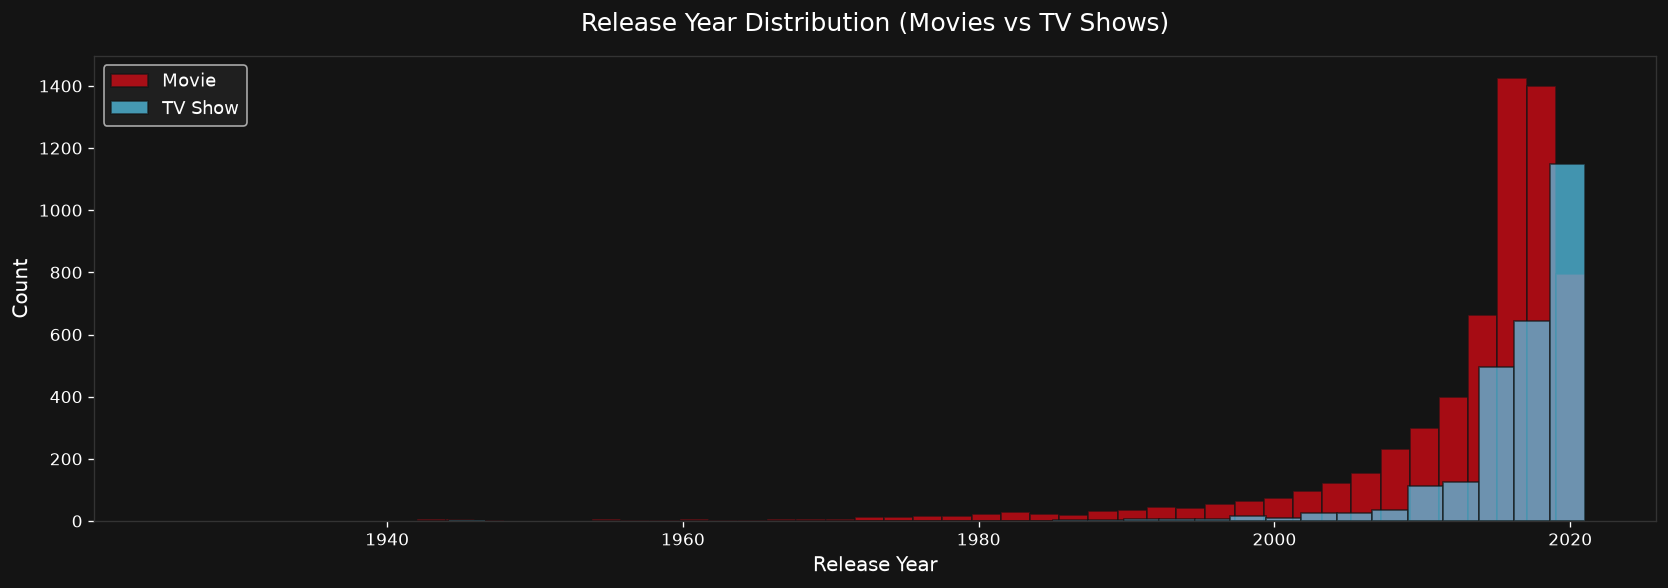

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

for ctype, color in [('Movie', NETFLIX_RED), ('TV Show', '#56CCF2')]:
    data = df_clean[df_clean['type'] == ctype]['release_year']
    ax.hist(data, bins=40, alpha=0.7, color=color, edgecolor=NETFLIX_DARK, label=ctype)

ax.set_title('Release Year Distribution (Movies vs TV Shows)', color='white', fontsize=15, pad=15)
ax.set_xlabel('Release Year', color='white', fontsize=12)
ax.set_ylabel('Count', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#222', labelcolor='white', fontsize=11)
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

### 5.9 📅 Which Month Has the Most Content Added?

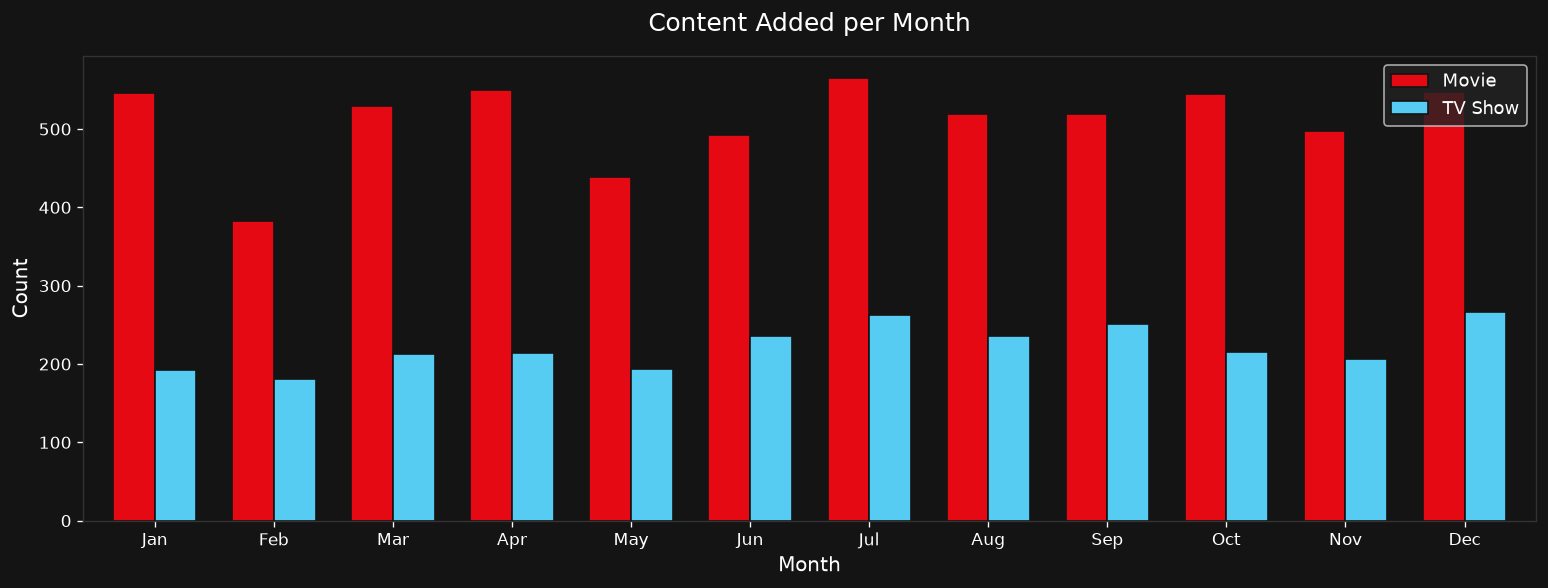

In [15]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly = df_clean.groupby(['month_name', 'type']).size().unstack(fill_value=0)
monthly = monthly.reindex([m for m in month_order if m in monthly.index])

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

monthly.plot(kind='bar', ax=ax, color=[NETFLIX_RED, '#56CCF2'], width=0.7, edgecolor=NETFLIX_DARK)

ax.set_title('Content Added per Month', color='white', fontsize=15, pad=15)
ax.set_xlabel('Month', color='white', fontsize=12)
ax.set_ylabel('Count', color='white', fontsize=12)
ax.tick_params(colors='white', rotation=0)
ax.legend(facecolor='#222', labelcolor='white', fontsize=11)
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

### 5.10 🗺️ Heatmap: Content Rating by Type

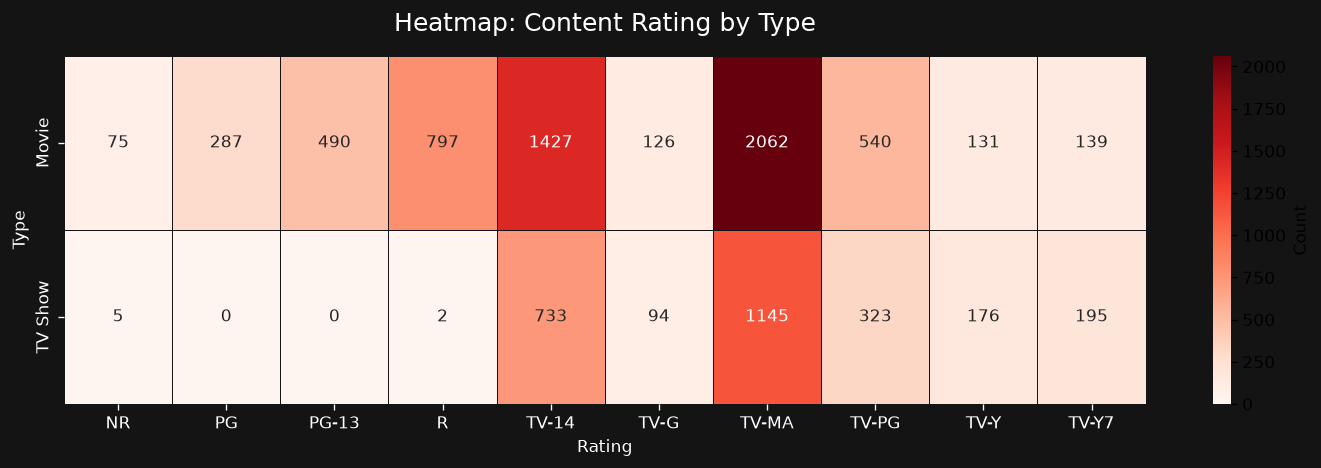

In [16]:
# Use only the top 10 most common ratings
top_ratings = df_clean['rating'].value_counts().head(10).index
heat_data   = (
    df_clean[df_clean['rating'].isin(top_ratings)]
    .groupby(['type', 'rating']).size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

sns.heatmap(
    heat_data, annot=True, fmt='d', cmap='Reds', ax=ax,
    linewidths=0.5, linecolor=NETFLIX_DARK,
    cbar_kws={'label': 'Count'}
)

ax.set_title('Heatmap: Content Rating by Type', color='white', fontsize=15, pad=15)
ax.set_xlabel('Rating', color='white')
ax.set_ylabel('Type', color='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

### 5.11 🌐 Top Countries by Content Type

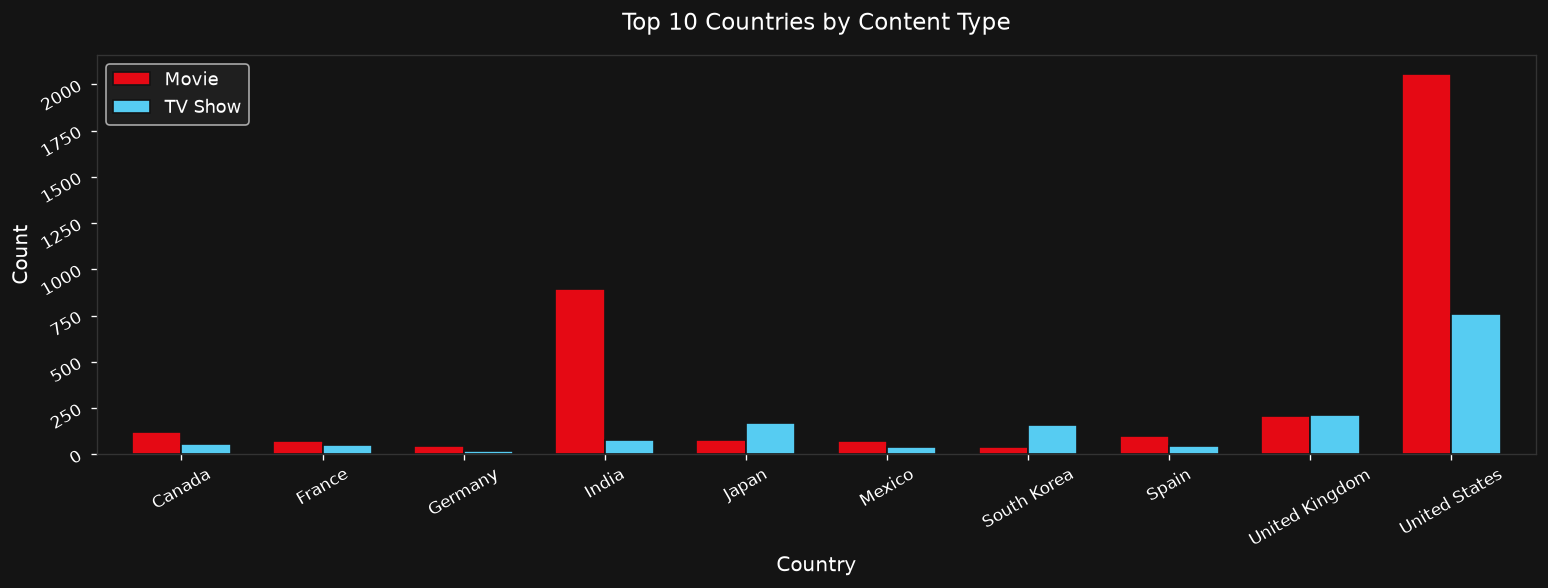

In [17]:
# Get top 10 countries, then group by country + type
top10 = df_clean['country'].dropna().str.split(', ').explode().value_counts().head(10).index

country_type = (
    df_clean[df_clean['country'].isin(top10)]
    .groupby(['country', 'type']).size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

country_type.plot(kind='bar', ax=ax, color=[NETFLIX_RED, '#56CCF2'], width=0.7, edgecolor=NETFLIX_DARK)

ax.set_title('Top 10 Countries by Content Type', color='white', fontsize=14, pad=15)
ax.set_xlabel('Country', color='white', fontsize=12)
ax.set_ylabel('Count', color='white', fontsize=12)
ax.tick_params(colors='white', rotation=30)
ax.legend(facecolor='#222', labelcolor='white', fontsize=11)
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

### 5.12 📊 Time Gap Between Release Year and Netflix Addition

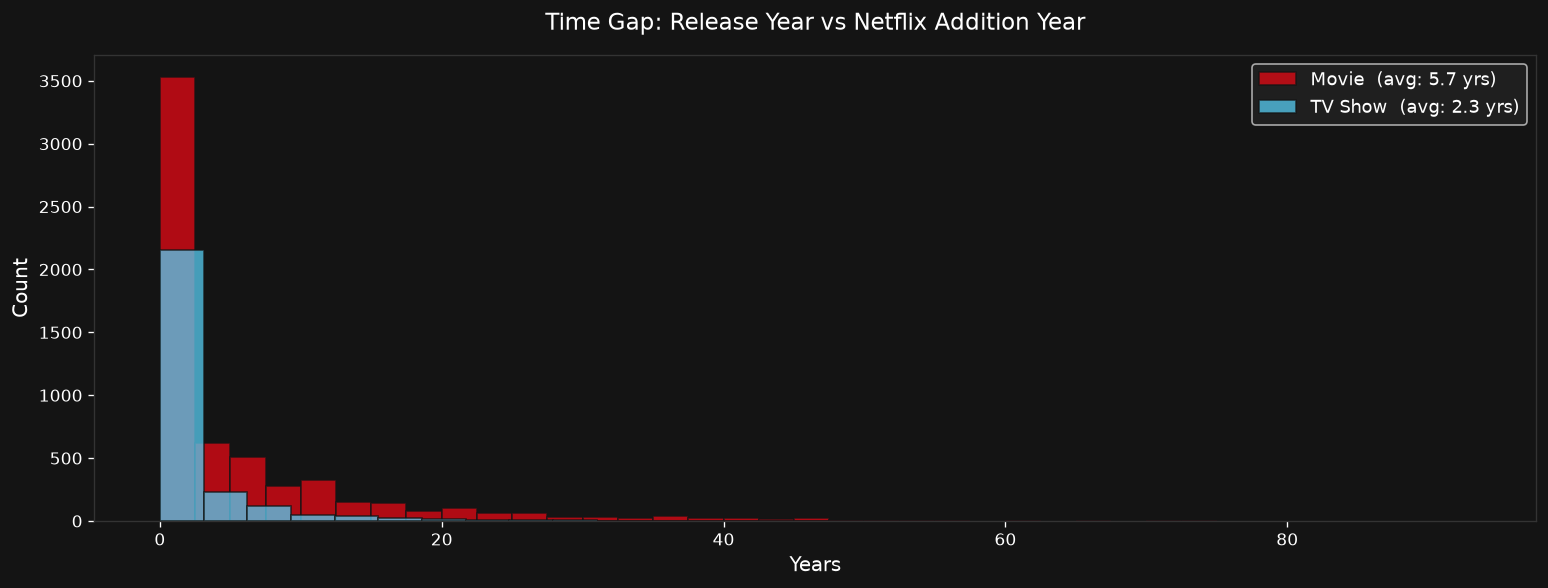

In [18]:
# Calculate the gap in years between original release and when it was added to Netflix
df_gap = df_clean.dropna(subset=['year_added']).copy()
df_gap = df_gap[df_gap['year_added'] >= 2008]
df_gap['gap_years'] = df_gap['year_added'] - df_gap['release_year']
df_gap = df_gap[df_gap['gap_years'] >= 0]  # Remove negative gaps (data errors)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

for ctype, color in [('Movie', NETFLIX_RED), ('TV Show', '#56CCF2')]:
    data = df_gap[df_gap['type'] == ctype]['gap_years']
    ax.hist(
        data, bins=30, alpha=0.75, color=color, edgecolor=NETFLIX_DARK,
        label=f'{ctype}  (avg: {data.mean():.1f} yrs)'
    )

ax.set_title('Time Gap: Release Year vs Netflix Addition Year', color='white', fontsize=14, pad=15)
ax.set_xlabel('Years', color='white', fontsize=12)
ax.set_ylabel('Count', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#222', labelcolor='white', fontsize=11)
ax.spines[:].set_color('#333')

plt.tight_layout()
plt.show()

## 📋 6. Summary

In [19]:
movies = df_clean[df_clean['type'] == 'Movie']
shows  = df_clean[df_clean['type'] == 'TV Show']

print('=' * 65)
print('         Netflix Dataset - Analysis Summary')
print('=' * 65)
print(f'\nTotal titles:             {len(df_clean):>7,}')
print(f'  Movies:                 {len(movies):>7,}  ({len(movies)/len(df_clean)*100:.1f}%)')
print(f'  TV Shows:               {len(shows):>7,}  ({len(shows)/len(df_clean)*100:.1f}%)')

print(f'\nMost active year added:   {int(df_clean["year_added"].mode()[0])}')
print(f'Top production country:   United States')
print(f'Most common genre:        International Movies')
print(f'Most common rating:       TV-MA')

print(f'\nAvg movie duration:       {movies["duration_min"].mean():.0f} minutes')
print(f'Avg seasons per show:     {shows["seasons"].mean():.1f} seasons')

print(f'\nOldest title year:        {int(df_clean["release_year"].min())}')
print(f'Newest title year:        {int(df_clean["release_year"].max())}')

print(f'\nMissing director info:    {df_clean["director"].isna().sum():,} rows')
print(f'Missing cast info:        {df_clean["cast"].isna().sum():,} rows')
print(f'Missing country info:     {df_clean["country"].isna().sum():,} rows')
print('=' * 65)

         Netflix Dataset - Analysis Summary

Total titles:               8,807
  Movies:                   6,131  (69.6%)
  TV Shows:                 2,676  (30.4%)

Most active year added:   2019
Top production country:   United States
Most common genre:        International Movies
Most common rating:       TV-MA

Avg movie duration:       100 minutes
Avg seasons per show:     1.8 seasons

Oldest title year:        1925
Newest title year:        2021

Missing director info:    2,634 rows
Missing cast info:        825 rows
Missing country info:     831 rows


---
## ✅ Analysis Complete!

| Insight | Finding |
|---------|----------|
| Content split | 69.6% Movies, 30.4% TV Shows |
| Top country | United States (3,689 titles) |
| Top genre | International Movies |
| Top rating | TV-MA (mature audience) |
| Avg movie length | ~99 minutes |
| Peak addition years | 2019 – 2020 |
| Oldest title | 1925 |
| Newest title | 2021 |
